# Semi-Supervised Learning Pipeline with HDBSCAN Clustering

Semi-Supervised Learning Pipeline with HDBSCAN
This notebook demonstrates a Semi-Supervised Learning (SSL) workflow. The goal is to improve a Random Forest classifier by leveraging unlabeled data through a combination of density-based clustering (HDBSCAN) and high-confidence pseudo-labeling.

1. Introduction & Objectives
The pipeline follows these core steps:

- Data Splitting: Divide training data into 50% labeled and 50% unlabeled sets.

- Baseline Training: Establish a performance floor using only the labeled data.

- Structural Discovery: Use HDBSCAN to find natural groupings in the unlabeled data.

- Pseudo-Labeling: Use the baseline model to predict labels for unlabeled clusters, keeping only the most confident predictions.

- Knowledge Incorporation: Retrain the model on the combined dataset (Labeled + Pseudo-labeled).

2. Environment Setup 

This section handles the necessary imports.

- Key Libraries: sklearn for modeling, hdbscan for clustering, and seaborn/matplotlib for visualization.

- Reproducibility: Sets a RANDOM_STATE = 42 to ensure that results are consistent across different runs.

In [7]:
# Imports and environment setup
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier

# Settings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sns.set(style='whitegrid', context='notebook')
print('Environment ready.')

Environment ready.


3. Configuration & Helpers

Instead of hard-coding values, this cell defines the "knobs" of the experiment:

- Thresholds: PSEUDO_THRESHOLD = 0.95 ensures we only trust the model when it is 95% sure.

- Clustering Params: Sets the minimum size for a cluster to be considered valid.

- Utility Functions: Includes logic to automatically find the label column (e.g., 'Attack' or 'Label') and filter for numeric features.

In [8]:
# Configuration and utilities
DATASET_CANDIDATES = [
    '../../../dataset/cicids2017_sample_1M_natural_standardized.csv',
]
LABEL_CANDIDATES = ['label', 'Label', 'Attack', 'class', 'Class', 'category', 'target', 'y']

# Semi-supervised settings
TEST_SIZE = 0.2
RECORD_LIMITS = {
    'mode': 'custom',   # 'all' or 'custom'
    'train_n': 100000,
    'test_n': 10000,
}
LABELED_FRAC = 0.5  # 50% labeled, 50% unlabeled
PSEUDO_THRESHOLD = 0.95  # confidence threshold for pseudo-labeling
SAMPLE_FRAC = None
RANDOM_STATE = 42

# HDBSCAN settings
HDBSCAN_MIN_CLUSTER_SIZE = 1000
HDBSCAN_MIN_SAMPLES = 100

def pick_existing_path(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    return None

def load_any_dataset(candidates):
    path = pick_existing_path(candidates)
    if path is None:
        raise FileNotFoundError('No dataset found in candidates: ' + str(candidates))
    ext = os.path.splitext(path)[1].lower()
    if ext in ['.parquet']:
        df = pd.read_parquet(path)
    else:
        df = pd.read_csv(path, low_memory=False)
    print(f'Loaded dataset: {path} | shape={df.shape}')
    return df

def find_label_col(df, candidates=LABEL_CANDIDATES):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError('Could not infer label column. Checked: ' + str(candidates))

def select_numeric_features(df):
    X_num = df.select_dtypes(include=[np.number])
    if X_num.shape[1] == 0:
        X_num = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
        X_num = X_num.select_dtypes(include=[np.number])
    return X_num

def stratified_labeled_unlabeled_split(X, y, labeled_frac=0.5, random_state=42):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=1 - labeled_frac, random_state=random_state)
    idx = np.arange(len(y))
    labeled_idx, unlabeled_idx = next(sss.split(idx, y))
    return labeled_idx, unlabeled_idx

def plot_conf_matrix(cm, classes, title='Confusion matrix'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()

print('Config ready.')

Config ready.


4. Data Preprocessing & Leakage Prevention 

This is a critical step for valid machine learning:

- Binary Encoding: Converts various attack names into a simple Normal (0) vs Abnormal (1) classification.

- Scaling: The StandardScaler is fitted only on the labeled data. This prevents "data leakage" (information from the test/unlabeled set "bleeding" into the training process).

In [ ]:
# Load, preprocess, and split data
df = load_any_dataset(DATASET_CANDIDATES)
if SAMPLE_FRAC and 0 < SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)

label_col = find_label_col(df)
df = df.dropna(how='any').reset_index(drop=True)

y_raw = df[label_col].astype(str)
X_num = select_numeric_features(df.drop(columns=[label_col]))

# Drop inf rows and extreme-value columns
inf_mask = np.isinf(X_num.values).any(axis=1)
if inf_mask.sum():
    X_num, y_raw = X_num[~inf_mask].reset_index(drop=True), y_raw[~inf_mask].reset_index(drop=True)
extreme_cols = (X_num.abs() > np.finfo(np.float64).max / 2).any()
if extreme_cols.any():
    X_num = X_num.loc[:, ~extreme_cols]

train_features = X_num.columns.tolist()

# Binary encode: Normal=0, Abnormal=1; stratify on original multi-class labels
le_full = LabelEncoder()
y_all = le_full.fit_transform(y_raw)
y_enc = np.where(y_raw.str.lower().isin(['benign', 'normal']), 0, 1).astype(int)
classes = ['Normal', 'Abnormal']
strat_y = y_all if np.bincount(y_all).min() >= 2 else y_enc

if RECORD_LIMITS.get('mode') == 'custom':
    train_n, test_n = RECORD_LIMITS.get('train_n'), RECORD_LIMITS.get('test_n')
    sss = StratifiedShuffleSplit(1, train_size=train_n, test_size=test_n, random_state=RANDOM_STATE)
    train_idx, test_idx = next(sss.split(np.arange(len(y_enc)), strat_y))
    X_train, X_test = X_num.values[train_idx], X_num.values[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_num.values, y_enc, test_size=TEST_SIZE, stratify=strat_y, random_state=RANDOM_STATE)

labeled_idx, unlabeled_idx = stratified_labeled_unlabeled_split(X_train, y_train, LABELED_FRAC, RANDOM_STATE)
X_labeled, y_labeled = X_train[labeled_idx], y_train[labeled_idx]
X_unlabeled = X_train[unlabeled_idx]

scaler = StandardScaler()
X_labeled_s   = scaler.fit_transform(X_labeled)
X_unlabeled_s = scaler.transform(X_unlabeled)
X_test_s      = scaler.transform(X_test)
print(f'Features={len(train_features)} | Train={X_train.shape[0]} (labeled={len(y_labeled)}, unlabeled={len(X_unlabeled)}) | Test={X_test.shape[0]}')


Loaded dataset: ../../../dataset/cicids2017_sample_1M_natural_standardized.csv | shape=(864031, 79)
Detected label column: Label
Dropping 275 rows containing inf/-inf values.
Using numeric features: 78
Binary classes: ['Normal', 'Abnormal']
Train: (100000, 78) Test: (10000, 78)
Labeled: (50000, 78) | Unlabeled: (50000, 78)
Scaling complete.


5. Baseline Supervised Model

We train a RandomForestClassifier on the small labeled subset.

- Purpose: To see how well a standard model performs when it has very limited data.

- Output: Generates a Classification Report and Confusion Matrix.

Baseline supervised (labeled fraction=0.50) results:
              precision    recall  f1-score   support

      Normal     0.9995    0.9995    0.9995      7418
    Abnormal     0.9985    0.9985    0.9985      2582

    accuracy                         0.9992     10000
   macro avg     0.9990    0.9990    0.9990     10000
weighted avg     0.9992    0.9992    0.9992     10000



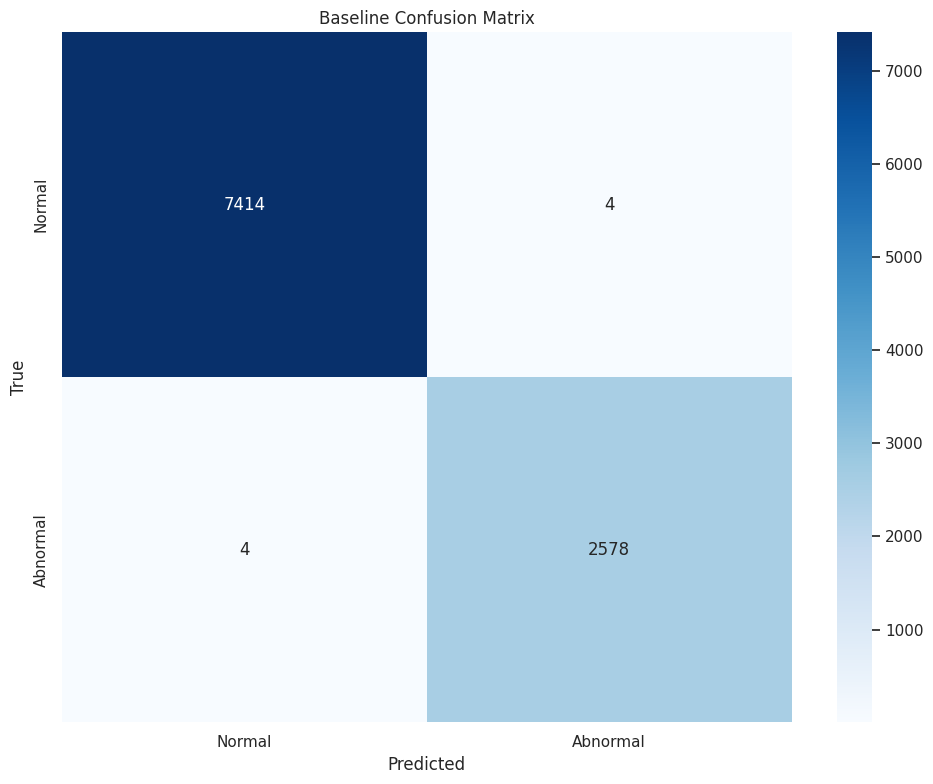

Baseline macro-F1: 0.9989557922101682


In [ ]:
# Baseline (labeled data only)
baseline = RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=RANDOM_STATE)
baseline.fit(X_labeled_s, y_labeled)
y_pred_base = baseline.predict(X_test_s)
print(classification_report(y_test, y_pred_base, labels=[0,1], target_names=classes, digits=4, zero_division=0))
plot_conf_matrix(confusion_matrix(y_test, y_pred_base), classes, 'Baseline Confusion Matrix')
print('Baseline macro-F1:', round(f1_score(y_test, y_pred_base, average='macro'), 4))


6. HDBSCAN Clustering & SSL Retraining 

The "Brain" of the notebook.

- HDBSCAN: Groups the unlabeled data. Points labeled as -1 are considered noise and are ignored to ensure high-quality training.

- Confidence Filter: We only accept pseudo-labels if they belong to a cluster AND the baseline model's predict_proba is >= 0.95.

- Retraining: A second Random Forest is trained on the augmented dataset.

--- Step 1: HDBSCAN clustering on unlabeled data ---
HDBSCAN found 9 clusters | noise points: 10550 / 50000


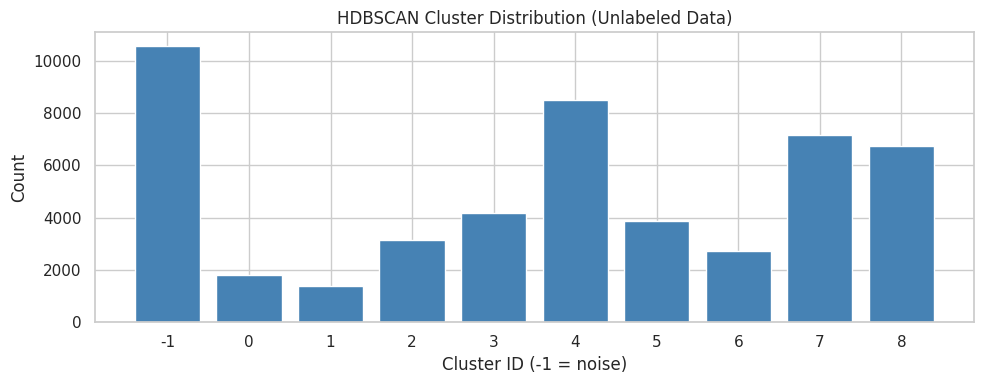


--- Step 2: Predict pseudo-labels with confidence filtering ---
Confident pseudo-labeled samples: 38967 / 50000 (77.9%)
  - Filtered by threshold >= 0.95 AND non-noise cluster
  Pseudo class Normal: 28190
  Pseudo class Abnormal: 10777

--- Step 3: Retrain model on labeled + pseudo-labeled data ---
Combined training set: 88967 samples (labeled=50000, pseudo=38967)

Semi-supervised (HDBSCAN + pseudo-labeling, threshold=0.95) results:
              precision    recall  f1-score   support

      Normal     0.9995    0.9996    0.9995      7418
    Abnormal     0.9988    0.9985    0.9986      2582

    accuracy                         0.9993     10000
   macro avg     0.9991    0.9990    0.9991     10000
weighted avg     0.9993    0.9993    0.9993     10000



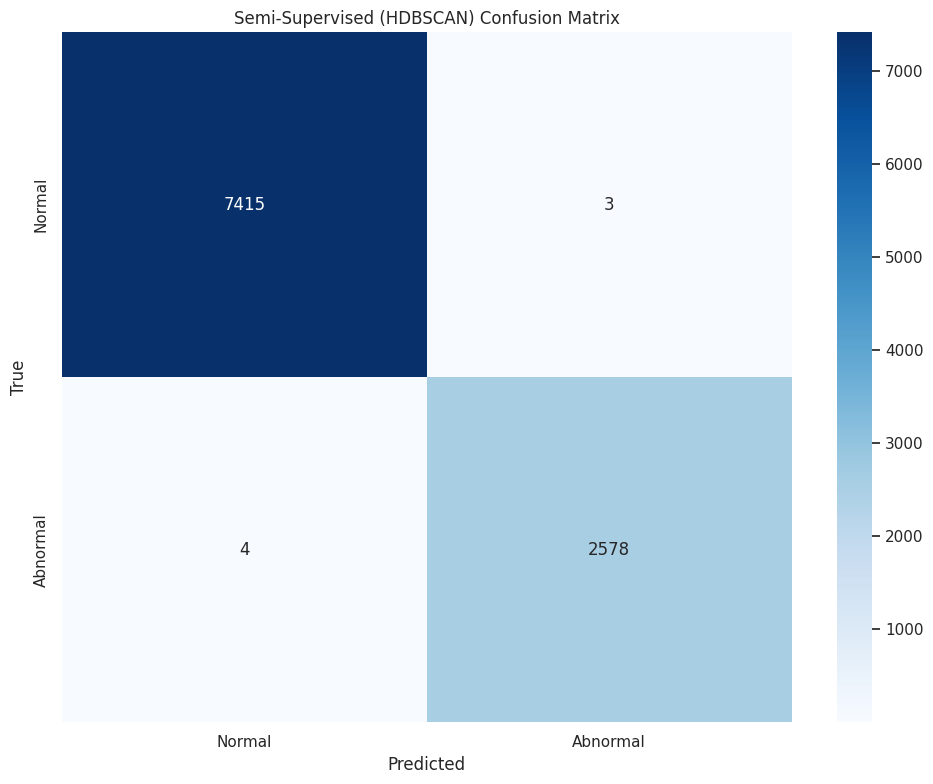

Baseline macro-F1:          0.9990
Semi-supervised macro-F1:   0.9991
Improvement:                +0.0001
Done.


In [ ]:
# Semi-Supervised: HDBSCAN + pseudo-labeling
clusterer = hdbscan.HDBSCAN(min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
                             min_samples=HDBSCAN_MIN_SAMPLES,
                             metric='euclidean', core_dist_n_jobs=-1)
cluster_labels = clusterer.fit_predict(X_unlabeled_s)
n_clusters = len(set(cluster_labels) - {-1})
print(f'Clusters: {n_clusters} | Noise: {(cluster_labels == -1).sum()}')

proba = baseline.predict_proba(X_unlabeled_s)
max_proba, pseudo_preds = proba.max(axis=1), baseline.predict(X_unlabeled_s)
confident_mask = (max_proba >= PSEUDO_THRESHOLD) & (cluster_labels != -1)
X_pseudo, y_pseudo = X_unlabeled_s[confident_mask], pseudo_preds[confident_mask]
print(f'Pseudo-labeled: {confident_mask.sum()}/{len(X_unlabeled_s)} ({confident_mask.mean()*100:.1f}%)')

X_combined = np.vstack([X_labeled_s, X_pseudo])
y_combined = np.concatenate([y_labeled, y_pseudo])

ssl = RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample',
                              n_jobs=-1, random_state=RANDOM_STATE)
ssl.fit(X_combined, y_combined)

y_pred_ssl = ssl.predict(X_test_s)
print(classification_report(y_test, y_pred_ssl, labels=[0,1], target_names=classes, digits=4, zero_division=0))
plot_conf_matrix(confusion_matrix(y_test, y_pred_ssl), classes, 'SSL (HDBSCAN) Confusion Matrix')
f1_base = f1_score(y_test, y_pred_base, average='macro')
f1_ssl  = f1_score(y_test, y_pred_ssl,  average='macro')
print(f'Macro-F1 — Baseline: {f1_base:.4f}  SSL: {f1_ssl:.4f}  Δ: {f1_ssl - f1_base:+.4f}')


7. Model Serialization 

Saves the trained models (baseline_rf.joblib and ssl_rf.joblib) along with the scaler and feature names into an artifacts/ folder for later deployment or testing.

In [12]:
# Save trained models and preprocessing artifacts
import joblib
ART_DIR = 'artifacts'
os.makedirs(ART_DIR, exist_ok=True)
saved = []

if 'baseline' in globals():
    joblib.dump({
        'model': baseline,
        'scaler': scaler,
        'features': train_features,
        'classes': classes,
        'label_encoding': {'normal': 0, 'abnormal': 1}
    }, os.path.join(ART_DIR, 'baseline_rf.joblib'))
    saved.append('baseline_rf.joblib')

if 'ssl' in globals():
    joblib.dump({
        'model': ssl,
        'scaler': scaler,
        'features': train_features,
        'classes': classes,
        'label_encoding': {'normal': 0, 'abnormal': 1},
        'threshold': PSEUDO_THRESHOLD,
        'hdbscan_params': {
            'min_cluster_size': HDBSCAN_MIN_CLUSTER_SIZE,
            'min_samples': HDBSCAN_MIN_SAMPLES,
        },
    }, os.path.join(ART_DIR, 'ssl_rf.joblib'))
    saved.append('ssl_rf.joblib')

print('Artifacts directory:', ART_DIR)
print('Saved files:', saved if saved else 'Nothing saved (train cells not executed yet).')

Artifacts directory: artifacts
Saved files: ['baseline_rf.joblib', 'ssl_rf.joblib']
